In [1]:
from math import sqrt

import numpy as np
import pandas as pd

# pysheds 0.5 calls np.in1d which was removed in NumPy 2.0
if not hasattr(np, "in1d"):
    np.in1d = lambda ar1, ar2, **kw: np.isin(ar1, ar2, **kw).ravel()

from pysheds.grid import Grid
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# D8 (Deterministic-8) Flow

- This relies on the GIS principle that water flows downstream
- The D stands for direction and 8 is the number of cells included in the calculation
- The idea is that the water will flow to its steepest neighbour

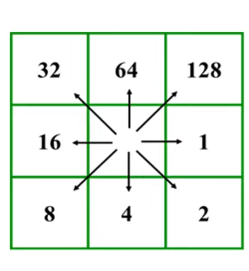


### Formula

$ S = \frac{\Delta z}{d} $

- $S$: slope
- $\Delta z$: difference in elevation
- $d$: distance between cell centres
  - 1 for N, S, E and W
  - $\sqrt 2$ for diagonals

### Basic Example

Each number is in metres and the index can be interpreted as coordinates. 

- `dem[0][:3]` will be abc
- `dem[1][:3]` will be def
- `dem[2][:3]` will be fgh

In [2]:
dem = np.array([
    [67, 56, 49],
    [53, 22, 37],
    [58, 55, 16]                
])
dem

array([[67, 56, 49],
       [53, 22, 37],
       [58, 55, 16]])

In [3]:
s_eh = (22 - 16) / sqrt((1 ** 2) + (1 ** 2)) # 22, 16
s_eh

4.242640687119285

In [4]:
def calculate_d8(array: np.ndarray, x1: int, y1: int, x2: int, y2: int) -> np.float64:
    z1 = array[x1][y1]
    z2 = array[x2][y2]
    delta_z = max(z1, z2) - min(z1, z2)
    d = 1
    # Set distance to sqrt(2) if diagonal
    if x1 != x2 or y1 != y2:
        d = sqrt((1**2) + (1**2))
    return delta_z / d


calculate_d8(dem, 1, 1, 2, 2)

np.float64(4.242640687119285)

## Practical Pysheds Example


### 1. Load DEM

Load the elevation model. The PRA will be derived directly from DEM slope — no external file needed.

Shape : (242, 218),  cell size: 25.7 m


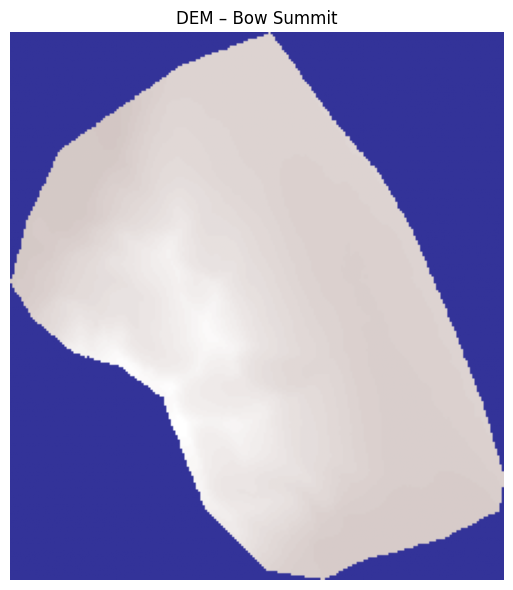

In [5]:
DEM_PATH = "../autoates_v2/test-data/Bow Summit/dem.tif"

grid = Grid.from_raster(DEM_PATH)
dem  = grid.read_raster(DEM_PATH)

cell_size = abs(grid.affine.a)
print(f"Shape : {dem.shape},  cell size: {cell_size:.1f} m")

plt.figure(figsize=(7, 6))
plt.imshow(dem, cmap="terrain")
plt.title("DEM – Bow Summit")
plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
dem

Raster([[-9999, -9999, -9999, ..., -9999, -9999, -9999],
        [-9999, -9999, -9999, ..., -9999, -9999, -9999],
        [-9999, -9999, -9999, ..., -9999, -9999, -9999],
        ...,
        [-9999, -9999, -9999, ..., -9999, -9999, -9999],
        [-9999, -9999, -9999, ..., -9999, -9999, -9999],
        [-9999, -9999, -9999, ..., -9999, -9999, -9999]],
       shape=(242, 218), dtype=int16)

### 2. Minimal DEM Conditioning

For avalanche routing we only fix single-cell pits (DEM artefacts). We deliberately skip `fill_depressions` and `resolve_flats` — those steps flatten bowls and cirques that are real avalanche terrain features and would corrupt the slope angles used by PRA.

In [7]:
dem_conditioned = grid.fill_pits(dem)

diff = np.array(dem_conditioned) - np.array(dem)
print(f"Single-cell pits filled: {(diff != 0).sum():,}")

Single-cell pits filled: 12


### 3. Derive PRA from Slope

The Potential Release Area is defined by Veitinger et al. as terrain with slope angles between **30° and 60°** — steep enough to release but not so steep that snow can't accumulate.

Slope is computed from the conditioned DEM using the central-difference gradient, scaled by cell size to get degrees.

Release cells: 7,197  (13.6% of area)


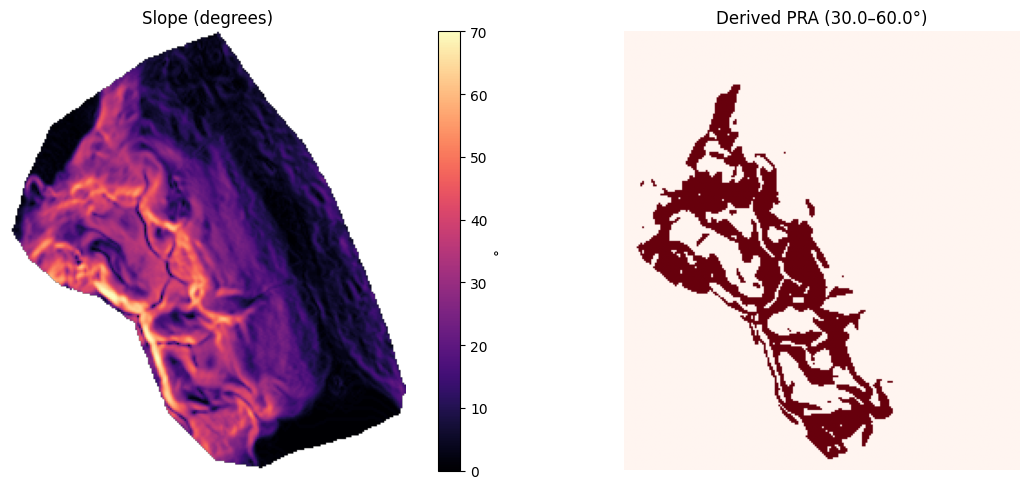

In [8]:
from pysheds.sview import Raster as PyShedsRaster

elev = np.where(np.array(dem_conditioned) == dem.nodata, np.nan, dem_conditioned).astype(float)

dz_dy, dz_dx = np.gradient(elev, cell_size)
slope_deg = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

PRA_MIN, PRA_MAX = 30.0, 60.0
pra_arr = ((slope_deg >= PRA_MIN) & (slope_deg <= PRA_MAX)).astype(np.float32)
pra_arr[np.isnan(slope_deg)] = 0.0

# Wrap as a pysheds Raster so grid.accumulation can access .nodata
pra = PyShedsRaster(pra_arr, viewfinder=dem.viewfinder)

print(f"Release cells: {int(pra_arr.sum()):,}  ({100 * pra_arr.mean():.1f}% of area)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(slope_deg, cmap="magma", vmin=0, vmax=70)
axes[0].set_title("Slope (degrees)")
axes[0].axis("off")
plt.colorbar(axes[0].images[0], ax=axes[0], label="°")
axes[1].imshow(pra_arr, cmap="Reds")
axes[1].set_title(f"Derived PRA ({PRA_MIN}–{PRA_MAX}°)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### 4. D8 Flow Direction

Compute the steepest-descent direction for every cell. This tells us where material (snow) leaving any cell would travel next.

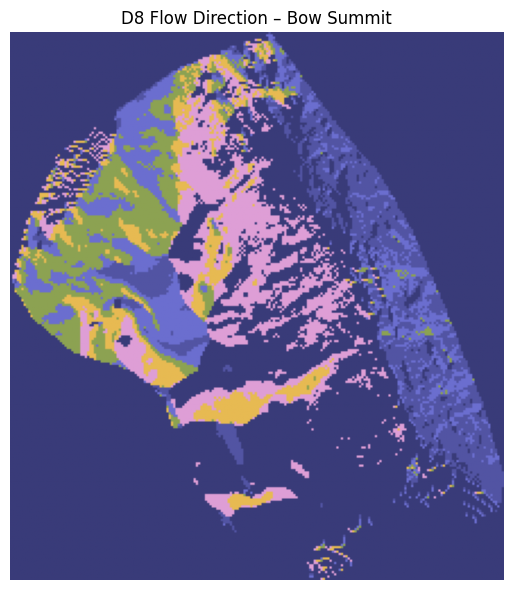

In [9]:
DIRMAP = (64, 128, 1, 2, 4, 8, 16, 32)  # E, NE, N, NW, W, SW, S, SE

fdir = grid.flowdir(dem_conditioned, dirmap=DIRMAP)

plt.figure(figsize=(7, 6))
plt.imshow(fdir, cmap="tab20b")
plt.title("D8 Flow Direction – Bow Summit")
plt.axis("off")
plt.tight_layout()
plt.show()

### 5. PRA-Weighted Accumulation → Avalanche Exposure

Weight the D8 accumulation by the slope-derived PRA. Each cell's value becomes the number of release-area cells that drain through it — a terrain exposure proxy for ATES classification.

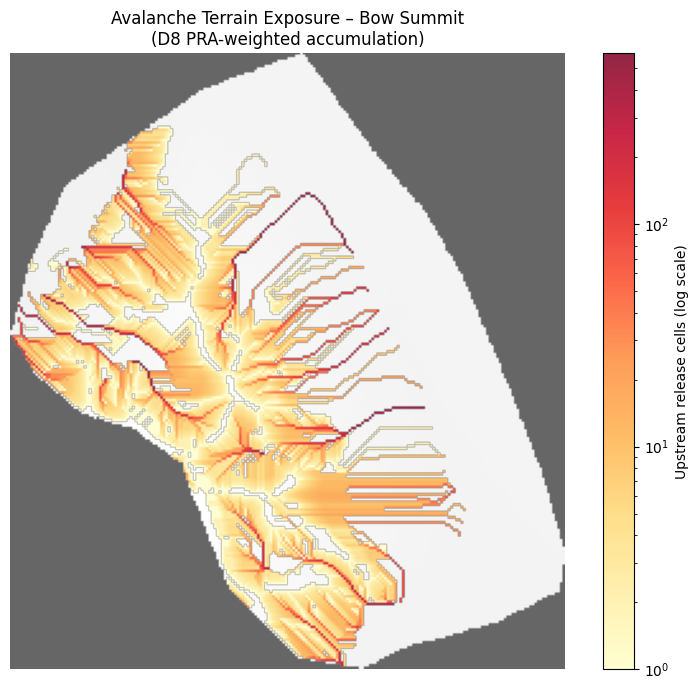

Max exposure : 586 release cells converging


In [10]:
exposure = grid.accumulation(fdir, weights=pra, dirmap=DIRMAP)

# Mask zero-exposure cells so the DEM hillshade shows through
exposure_masked = np.where(exposure > 0, exposure, np.nan)

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(dem, cmap="gray", alpha=0.6)
im = ax.imshow(
    exposure_masked,
    norm=colors.LogNorm(vmin=1, vmax=np.nanmax(exposure_masked)),
    cmap="YlOrRd",
    alpha=0.85,
)
plt.colorbar(im, ax=ax, label="Upstream release cells (log scale)")
ax.set_title("Avalanche Terrain Exposure – Bow Summit\n(D8 PRA-weighted accumulation)")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Max exposure : {int(exposure.max()):,} release cells converging")

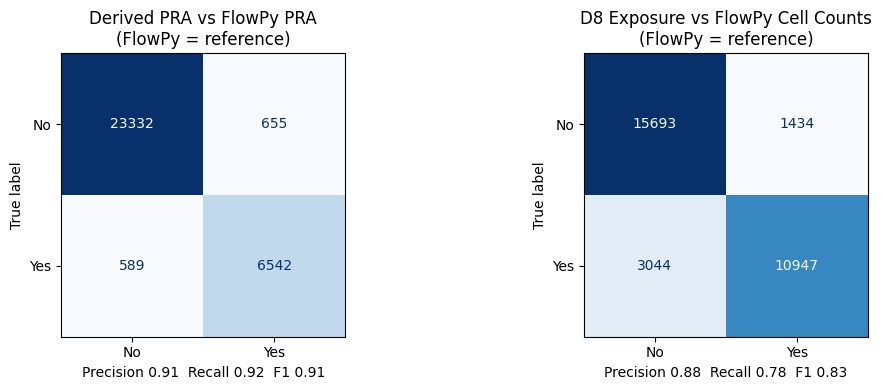

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

FP_COUNTS_PATH = "../autoates_v2/test-data/Bow Summit/cell_counts.tif"
FP_PRA_PATH    = "../autoates_v2/test-data/Bow Summit/pra_binary.tif"

fp_counts = grid.read_raster(FP_COUNTS_PATH)
fp_pra    = grid.read_raster(FP_PRA_PATH)

valid = (np.array(dem) != dem.nodata).ravel()

def show_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall    = tp / (tp + fn) if (tp + fn) else 0
    f1        = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0
    ax.set_xlabel(f"Precision {precision:.2f}  Recall {recall:.2f}  F1 {f1:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

show_cm(
    (np.array(fp_pra).ravel() > 0)[valid].astype(int),
    (pra_arr.ravel() > 0)[valid].astype(int),
    "Derived PRA vs FlowPy PRA\n(FlowPy = reference)",
    axes[0],
)

show_cm(
    (np.array(fp_counts).ravel() > 0)[valid].astype(int),
    (np.array(exposure).ravel() > 0)[valid].astype(int),
    "D8 Exposure vs FlowPy Cell Counts\n(FlowPy = reference)",
    axes[1],
)

plt.tight_layout()
plt.show()